# Project 05 — Full FLAN-T5 LoRA Training, Evaluation, and Release Pipeline

This notebook upgrades Project 05 from a code scaffold into a measured portfolio experiment. It performs the same artifact-oriented workflow used in strong notebook projects:

1. verify the RTX/CUDA environment;
2. generate and validate an expanded custom ML/Data Science instruction dataset;
3. block training until the dataset sample is reviewed;
4. fine-tune `google/flan-t5-base` with LoRA/PEFT;
5. save adapter weights, tokenizer, metadata, logs, and a real training curve;
6. evaluate the base and LoRA models on the same 80-example held-out benchmark;
7. calculate BERTScore, ROUGE-L, semantic similarity, instruction adherence, response quality, latency, and hallucination-risk flags;
8. calculate bootstrap confidence intervals and category-level comparisons;
9. save all JSON, CSV, Markdown, and PNG results automatically;
10. promote reviewed artifacts into the deployment folders and prepare Git/Hugging Face commands.

> **Responsible use:** This educational model can produce incorrect or hallucinated content. Do not use it for legal, medical, financial, immigration, safety-critical, or official decisions.

## 0. Open the notebook correctly

Open a terminal in `05-instruction-tuned-domain-llm`, activate your Python environment, and start Jupyter from that folder. The notebook automatically resolves the project root whether it is opened from the project folder or the `notebooks` folder.

In [1]:
from pathlib import Path
import os, sys, json, shutil, hashlib
from datetime import datetime

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROJECT_ROOT = PROJECT_ROOT.resolve()
sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)
assert (PROJECT_ROOT / "src").exists(), "Open Jupyter from the Project 05 folder or its notebooks folder."

Project root: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\05-instruction-tuned-domain-llm


## 1. Install the training and evaluation environment

Run this cell once in the selected environment. For an NVIDIA GPU, install a CUDA-enabled PyTorch build appropriate for your driver before running the requirements command if your current PyTorch is CPU-only.

In [ ]:
# Run once, then restart the kernel if packages were upgraded.
!python -m pip install -r "{PROJECT_ROOT / 'requirements-training.txt'}"

## 2. Experiment controls

The quality preset targets `google/flan-t5-base`. Dataset generation uses a local Qwen teacher model only to draft candidate examples; the final assistant remains FLAN-T5 + LoRA. The teacher-generated data must be sampled and reviewed before training.

In [2]:
RUN_DATASET_GENERATION = True
RUN_TRAINING = True
RUN_EVALUATION = True
PROMOTE_REVIEWED_ARTIFACTS = False
PUSH_ADAPTER_TO_HUB = False

RUN_NAME = datetime.now().strftime("flan_t5_base_lora_%Y%m%d_%H%M%S")
TARGET_DATASET_EXAMPLES = 600
TEACHER_MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
BASE_MODEL_ID = "google/flan-t5-base"
NUM_TRAIN_EPOCHS = 6.0
LEARNING_RATE = 1e-4
LORA_R = 16
LORA_ALPHA = 32

# Fill these only when you are ready to publish.
HF_USERNAME = "YOUR_HUGGINGFACE_USERNAME"
HF_ADAPTER_REPO = f"{HF_USERNAME}/flan-t5-base-ml-ds-lora"

RUN_DIR = PROJECT_ROOT / "outputs" / "experiments" / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)
print("Run directory:", RUN_DIR)

Run directory: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\05-instruction-tuned-domain-llm\outputs\experiments\flan_t5_base_lora_20260730_120312


## 3. RTX, CUDA, and reproducibility check

The report is saved to the experiment folder. The notebook uses BF16 where supported, otherwise FP16. Batch size and gradient accumulation are selected from available VRAM.

In [3]:
import torch
from src.hardware_utils import detect_hardware, save_hardware_report

hardware = detect_hardware()
display(hardware.to_dict())
save_hardware_report(RUN_DIR / "hardware_report.json", hardware)

assert torch.cuda.is_available(), (
    "CUDA is not available. Install a CUDA-enabled PyTorch build and verify your NVIDIA driver."
)
print("CUDA device:", torch.cuda.get_device_name(0))
print("Recommended model:", hardware.recommended_model_id)
print("Precision:", hardware.recommended_precision)

{'python_version': '3.12.10',
 'platform': 'Windows-11-10.0.26200-SP0',
 'torch_version': '2.12.1+cu132',
 'cuda_available': True,
 'cuda_version': '13.2',
 'cudnn_version': '92000',
 'gpu_name': 'NVIDIA GeForce RTX 5090',
 'gpu_vram_gb': 31.84,
 'compute_capability': '12.0',
 'bf16_supported': True,
 'recommended_precision': 'bf16',
 'recommended_model_id': 'google/flan-t5-base',
 'train_batch_size': 8,
 'eval_batch_size': 8,
 'gradient_accumulation_steps': 2,
 'gradient_checkpointing': False,
 'dataloader_num_workers': 4}

CUDA device: NVIDIA GeForce RTX 5090
Recommended model: google/flan-t5-base
Precision: bf16


## 4. Inspect the held-out benchmark

The 80 benchmark records are self-authored and separate from training. Dataset generation performs a similarity-based leakage check against these instructions.

In [4]:
import pandas as pd
from src.data_preprocessing import load_jsonl

benchmark_path = PROJECT_ROOT / "data" / "benchmark_prompts_v2.jsonl"
benchmark_records = load_jsonl(benchmark_path)
benchmark_df = pd.DataFrame(benchmark_records)
print("Benchmark examples:", len(benchmark_df))
display(benchmark_df[["id", "instruction", "category", "difficulty", "topic"]].head(10))
display(benchmark_df["category"].value_counts())

Benchmark examples: 80


,id,instruction,category,difficulty,topic
0,benchmark_v2_000,Explain supervised learning accurately and inc...,Concept explanation,intermediate,supervised learning
1,benchmark_v2_001,Give a non-confidential quality analytics exam...,Quality analytics,intermediate,supervised learning
2,benchmark_v2_002,Explain unsupervised learning accurately and i...,Concept explanation,intermediate,unsupervised learning
3,benchmark_v2_003,Give a non-confidential quality analytics exam...,Quality analytics,intermediate,unsupervised learning
4,benchmark_v2_004,Explain classification accurately and include ...,Concept explanation,intermediate,classification
5,benchmark_v2_005,Give a non-confidential quality analytics exam...,Quality analytics,intermediate,classification
6,benchmark_v2_006,Explain regression accurately and include one ...,Concept explanation,intermediate,regression
7,benchmark_v2_007,Give a non-confidential quality analytics exam...,Quality analytics,intermediate,regression
8,benchmark_v2_008,Explain data leakage accurately and include on...,Concept explanation,intermediate,data leakage
9,benchmark_v2_009,Give a non-confidential quality analytics exam...,Quality analytics,intermediate,data leakage


category
Quality analytics      40
Concept explanation    31
Metric explanation      9
Name: count, dtype: int64

## 5. Generate the enhanced dataset

This stage combines the original 93 seed examples with locally generated candidate records. It then validates fields, removes empty/short/long records, removes near-duplicate instructions, removes records too similar to the benchmark, assigns stratified splits, and writes a detailed quality report.

In [5]:
from src.config import DatasetGenerationConfig
from src.dataset_expansion import generate_enhanced_dataset

enhanced_dataset_path = PROJECT_ROOT / "data" / "ml_ds_instruction_dataset_v2.jsonl"

if RUN_DATASET_GENERATION:
    dataset_report = generate_enhanced_dataset(
        seed_dataset_path=PROJECT_ROOT / "data" / "ml_ds_instruction_dataset.jsonl",
        topic_plan_path=PROJECT_ROOT / "data" / "dataset_generation_plan.json",
        benchmark_path=benchmark_path,
        output_dataset_path=enhanced_dataset_path,
        output_dir=RUN_DIR / "dataset_generation",
        config=DatasetGenerationConfig(
            teacher_model_id=TEACHER_MODEL_ID,
            target_examples=TARGET_DATASET_EXAMPLES,
        ),
    )
    display(dataset_report)
else:
    print("Dataset generation skipped; using", enhanced_dataset_path)

assert enhanced_dataset_path.exists(), "Enhanced dataset was not created."

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\05-instruction-tuned-domain-llm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\05-instruction-tuned-domain-llm\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\atripathi\.cache\huggingface\hub\models--Qwen--Qwen2.5-1.5B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingfa

{'status': 'completed_pending_human_review',
 'teacher_model_id': 'Qwen/Qwen2.5-1.5B-Instruct',
 'configuration': {'teacher_model_id': 'Qwen/Qwen2.5-1.5B-Instruct',
  'target_examples': 600,
  'temperature': 0.55,
  'top_p': 0.9,
  'max_new_tokens': 1800,
  'examples_per_topic': 8,
  'seed': 42,
  'duplicate_similarity_threshold': 0.88,
  'benchmark_leakage_threshold': 0.78},
 'hardware': {'python_version': '3.12.10',
  'platform': 'Windows-11-10.0.26200-SP0',
  'torch_version': '2.12.1+cu132',
  'cuda_available': True,
  'cuda_version': '13.2',
  'cudnn_version': '92000',
  'gpu_name': 'NVIDIA GeForce RTX 5090',
  'gpu_vram_gb': 31.84,
  'compute_capability': '12.0',
  'bf16_supported': True,
  'recommended_precision': 'bf16',
  'recommended_model_id': 'google/flan-t5-base',
  'train_batch_size': 8,
  'eval_batch_size': 8,
  'gradient_accumulation_steps': 2,
  'gradient_checkpointing': False,
  'dataloader_num_workers': 4},
 'seed_examples': 93,
 'raw_generated_examples': 468,
 'valid

## 6. Validate, visualize, and review the dataset

Do not approve the dataset based only on counts. Review random records from every category and all code/advanced records. Correct or remove weak examples directly in `data/ml_ds_instruction_dataset_v2.jsonl`, then rerun this section.

In [6]:
from src.data_preprocessing import validate_and_clean_records, split_records
from src.dataset_expansion import dataset_statistics
from src.visualization import create_dataset_visualizations

records = load_jsonl(enhanced_dataset_path)
cleaned_records, validation_report = validate_and_clean_records(records, min_output_words=20, max_output_words=260)
splits = split_records(cleaned_records)

print(json.dumps(validation_report.to_dict(), indent=2))
print(json.dumps(dataset_statistics(cleaned_records), indent=2))
assert len(cleaned_records) >= 450, "Dataset is still too small for the quality target; inspect generation failures."
assert len(splits["validation"]) >= 40, "Validation split is smaller than the target."
assert len(splits["test"]) >= 40, "Internal test split is smaller than the target."

create_dataset_visualizations(cleaned_records, RUN_DIR / "dataset_generation")
dataset_df = pd.DataFrame(cleaned_records)
display(dataset_df.groupby(["category", "difficulty"]).size().unstack(fill_value=0))

{
  "total_records": 543,
  "valid_records": 543,
  "removed_records": 0,
  "empty_instructions": 0,
  "empty_outputs": 0,
  "duplicate_instructions": 0,
  "too_short_outputs": 0,
  "too_long_outputs": 0,
  "possible_pii": 0,
  "confidential_references": 0
}
{
  "total_examples": 543,
  "split_counts": {
    "test": 56,
    "train": 434,
    "validation": 53
  },
  "category_counts": {
    "Metric explanation": 20,
    "Concept explanation": 346,
    "Algorithm comparison": 63,
    "Example generation": 34,
    "Beginner-friendly explanation": 25,
    "Data Science workflow": 9,
    "Interview-style answer": 12,
    "ML project guidance": 11,
    "Small code example": 13,
    "Quality analytics": 10
  },
  "difficulty_counts": {
    "intermediate": 361,
    "advanced": 65,
    "beginner": 117
  },
  "topic_count": 88,
  "average_instruction_words": 11.39,
  "average_output_words": 50.27,
  "min_output_words": 20,
  "max_output_words": 150
}


difficulty,advanced,beginner,intermediate
category,,,
Algorithm comparison,7,7,49
Beginner-friendly explanation,0,24,1
Concept explanation,48,68,230
Data Science workflow,0,0,9
Example generation,2,13,19
Interview-style answer,5,0,7
ML project guidance,2,0,9
Metric explanation,1,1,18
Quality analytics,0,0,10


In [8]:
# Stratified review sample: review at least two examples per category.
review_sample = pd.concat(
    [
        group.sample(
            n=min(2, len(group)),
            random_state=42
        )
        for _, group in dataset_df.groupby(
            "category",
            sort=True
        )
    ],
    ignore_index=True
)

review_columns = [
    "instruction",
    "output",
    "category",
    "difficulty",
    "topic",
    "source",
]

display(review_sample[review_columns])

# Also inspect all advanced and small-code examples separately.
advanced_or_code = dataset_df[
    (dataset_df["difficulty"].str.lower() == "advanced")
    | (dataset_df["category"].str.lower() == "small code example")
].copy()

advanced_columns = [
    "id",
    "instruction",
    "output",
    "category",
    "difficulty",
    "topic",
]

display(
    advanced_or_code[advanced_columns]
    .sort_values(["category", "topic", "id"])
    .reset_index(drop=True)
    .head(100)
)

,instruction,output,category,difficulty,topic,source
0,Compare random forest and gradient boosting.,Random forest builds many independent trees an...,Algorithm comparison,intermediate,ensemble learning,self-authored-synthetic
1,Compare k-means clustering to hierarchical clu...,K-means clustering starts by randomly selectin...,Algorithm comparison,beginner,k-means clustering,local-teacher-synthetic-reviewed
2,Explain the concept of R-squared in simple terms.,R-squared measures the proportion of the varia...,Beginner-friendly explanation,beginner,R-squared,local-teacher-synthetic-reviewed
3,Explain one-hot encoding in beginner-friendly ...,One-hot encoding turns each category into its ...,Beginner-friendly explanation,beginner,machine learning fundamentals,self-authored-synthetic
4,Why is it important to validate the effectiven...,Validation is crucial because imputation can i...,Concept explanation,intermediate,missing-value handling,local-teacher-synthetic-reviewed
5,How does k-Nearest Neighbors compare to k-Near...,k-NN is generally less accurate than k-NN beca...,Concept explanation,intermediate,k-nearest neighbors,local-teacher-synthetic-reviewed
6,How do you preprocess text data before feeding...,Before feeding text data into an RNN for senti...,Data Science workflow,intermediate,RNN,local-teacher-synthetic-reviewed
7,How does PCA handle missing data in a dataset?,PCA can handle missing data by imputing the mi...,Data Science workflow,intermediate,principal component analysis,local-teacher-synthetic-reviewed
8,Generate a realistic example of a classificati...,This dataset contains information such as cust...,Example generation,beginner,classification,local-teacher-synthetic-reviewed
9,Provide an example of how to implement Precisi...,To calculate Precision-Recall (PR) AUC in Pyth...,Example generation,intermediate,PR-AUC,local-teacher-synthetic-reviewed


,id,instruction,output,category,difficulty,topic
0,ml_ds_v2_00390,How does the vanishing gradient problem affect...,"To mitigate the vanishing gradient problem, te...",Algorithm comparison,advanced,RNN
1,ml_ds_v2_00239,How do you optimize the ROC-AUC score for a ma...,Optimizing the ROC-AUC score involves carefull...,Algorithm comparison,advanced,ROC-AUC
2,ml_ds_v2_00353,What is the role of momentum in improving the ...,Momentum is a technique used in backpropagatio...,Algorithm comparison,advanced,backpropagation
3,ml_ds_v2_00376,Describe the impact of Batch Normalization on ...,Batch Normalization typically leads to a small...,Algorithm comparison,advanced,batch normalization
4,ml_ds_v2_00113,Compare z-score normalization vs. min-max scal...,Z-score normalization effectively removes outl...,Algorithm comparison,advanced,standardization
...,...,...,...,...,...,...
73,ml_ds_0068,Show how to save a scikit-learn pipeline.,"```python import joblib joblib.dump(model, ""mo...",Small code example,intermediate,model deployment
74,ml_ds_0066,Show a simple cross-validation example.,```python from sklearn.model_selection import ...,Small code example,intermediate,model validation
75,ml_ds_v2_00164,Provide an example of how to implement an SVM ...,```python from sklearn.svm import SVC from skl...,Small code example,beginner,support vector machine
76,ml_ds_v2_00273,Generate a small code example demonstrating ho...,"```python def time_series_validation(data, int...",Small code example,beginner,time-series validation


### Human dataset approval gate

After reviewing and correcting the dataset, change the variable below to `True`. This creates an explicit audit trail that the synthetic candidate data was not blindly accepted.

In [10]:
DATASET_HUMAN_REVIEW_APPROVED = True  # Dataset reviewed and approved.

if RUN_TRAINING and not DATASET_HUMAN_REVIEW_APPROVED:
    raise RuntimeError(
        "Training blocked: review the stratified sample and advanced/code records, then set "
        "DATASET_HUMAN_REVIEW_APPROVED = True."
    )

## 7. Review the LoRA training configuration

The hardware-aware resolver keeps an effective batch size near 16. Early stopping and best-checkpoint loading use validation loss. Training logs, test loss, perplexity, package versions, hardware details, tokenizer, and adapter weights are saved automatically.

In [11]:
from dataclasses import replace
from src.config import LoraTrainingConfig, ModelConfig
from src.model_training import resolve_training_config

model_config = ModelConfig(base_model_id=BASE_MODEL_ID)
training_config = replace(
    LoraTrainingConfig(),
    num_train_epochs=NUM_TRAIN_EPOCHS,
    learning_rate=LEARNING_RATE,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
)
resolved_training_config = resolve_training_config(training_config, hardware)
display(model_config)
display(resolved_training_config)
print("Effective train batch size:", resolved_training_config.per_device_train_batch_size * resolved_training_config.gradient_accumulation_steps)

ModelConfig(base_model_id='google/flan-t5-base', adapter_id='', local_adapter_path='C:\\Users\\atripathi\\OneDrive - Veralto\\Desktop\\AI Codes\\GIT Projects\\transformer-projects\\05-instruction-tuned-domain-llm\\models\\lora_adapter', max_input_length=512, max_target_length=256, device='auto', torch_dtype='auto', trust_remote_code=False)

LoraTrainingConfig(r=16, lora_alpha=32, lora_dropout=0.05, target_modules=('q', 'v'), learning_rate=0.0001, num_train_epochs=6.0, per_device_train_batch_size=8, per_device_eval_batch_size=8, gradient_accumulation_steps=2, warmup_ratio=0.08, weight_decay=0.01, logging_steps=10, save_total_limit=2, seed=42, lr_scheduler_type='cosine', label_smoothing_factor=0.05, max_grad_norm=1.0, early_stopping_patience=2, gradient_checkpointing=False, dataloader_num_workers=4, group_by_length=True, optim='adamw_torch')

Effective train batch size: 16


## 8. Train the FLAN-T5-base LoRA adapter

This is the main GPU stage. The output includes `adapter_model.safetensors`, `adapter_config.json`, tokenizer files, `trainer_state.json`, `training_log_history.json`, `training_log_history.csv`, `training_curve.png`, `model_metadata.json`, validation metrics, and internal test loss.

In [12]:
from src.model_training import train_lora_adapter

training_dir = RUN_DIR / "training"
if RUN_TRAINING:
    training_metadata = train_lora_adapter(
        enhanced_dataset_path,
        training_dir,
        model_config=model_config,
        training_config=training_config,
        hardware_profile=hardware,
    )
    display(training_metadata)
else:
    training_metadata = json.loads((training_dir / "model_metadata.json").read_text())

adapter_path = training_dir / "lora_adapter"
assert (adapter_path / "adapter_config.json").exists()
assert (adapter_path / "adapter_model.safetensors").exists()
print("Adapter saved to:", adapter_path)

Loading weights: 100%|██████████| 282/282 [00:00<00:00, 2204.66it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
Tokenizing test split: 100%|██████████| 56/56 [00:00<00:00, 6578.56 examples/s]
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 1,769,472 || all params: 249,347,328 || trainable%: 0.7096


Epoch,Training Loss,Validation Loss
1,7.726540,3.522407
2,7.604623,3.438183
3,7.411715,3.400724
4,7.258554,3.382704
5,6.840746,3.376111
6,7.296616,3.375510


[transformers] early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled


Training Loss,Validation Loss,Epoch
7.296616,3.375510,6


[transformers] early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled


Training Loss,Validation Loss,Epoch
7.296616,3.424408,6


{'status': 'completed',
 'base_model': 'google/flan-t5-base',
 'fine_tuning_method': 'LoRA/PEFT',
 'adapter_path': 'C:\\Users\\atripathi\\OneDrive - Veralto\\Desktop\\AI Codes\\GIT Projects\\transformer-projects\\05-instruction-tuned-domain-llm\\outputs\\experiments\\flan_t5_base_lora_20260730_120312\\training\\lora_adapter',
 'tokenizer_path': 'C:\\Users\\atripathi\\OneDrive - Veralto\\Desktop\\AI Codes\\GIT Projects\\transformer-projects\\05-instruction-tuned-domain-llm\\outputs\\experiments\\flan_t5_base_lora_20260730_120312\\training\\tokenizer',
 'dataset_path': 'C:\\Users\\atripathi\\OneDrive - Veralto\\Desktop\\AI Codes\\GIT Projects\\transformer-projects\\05-instruction-tuned-domain-llm\\data\\ml_ds_instruction_dataset_v2.jsonl',
 'dataset_validation': {'total_records': 543,
  'valid_records': 543,
  'removed_records': 0,
  'empty_instructions': 0,
  'empty_outputs': 0,
  'duplicate_instructions': 0,
  'too_short_outputs': 0,
  'too_long_outputs': 0,
  'possible_pii': 0,
  'con

Adapter saved to: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\05-instruction-tuned-domain-llm\outputs\experiments\flan_t5_base_lora_20260730_120312\training\lora_adapter


## 9. Inspect the real training artifacts

{
  "train_runtime": 370.5182,
  "train_samples_per_second": 7.028,
  "train_steps_per_second": 0.453,
  "total_flos": 483221493448704.0,
  "train_loss": 7.259038053807759,
  "epoch": 6.0
}
{
  "validation_loss": 3.375509738922119
}
{
  "test_loss": 3.424408435821533
}
Validation perplexity: 29.239184


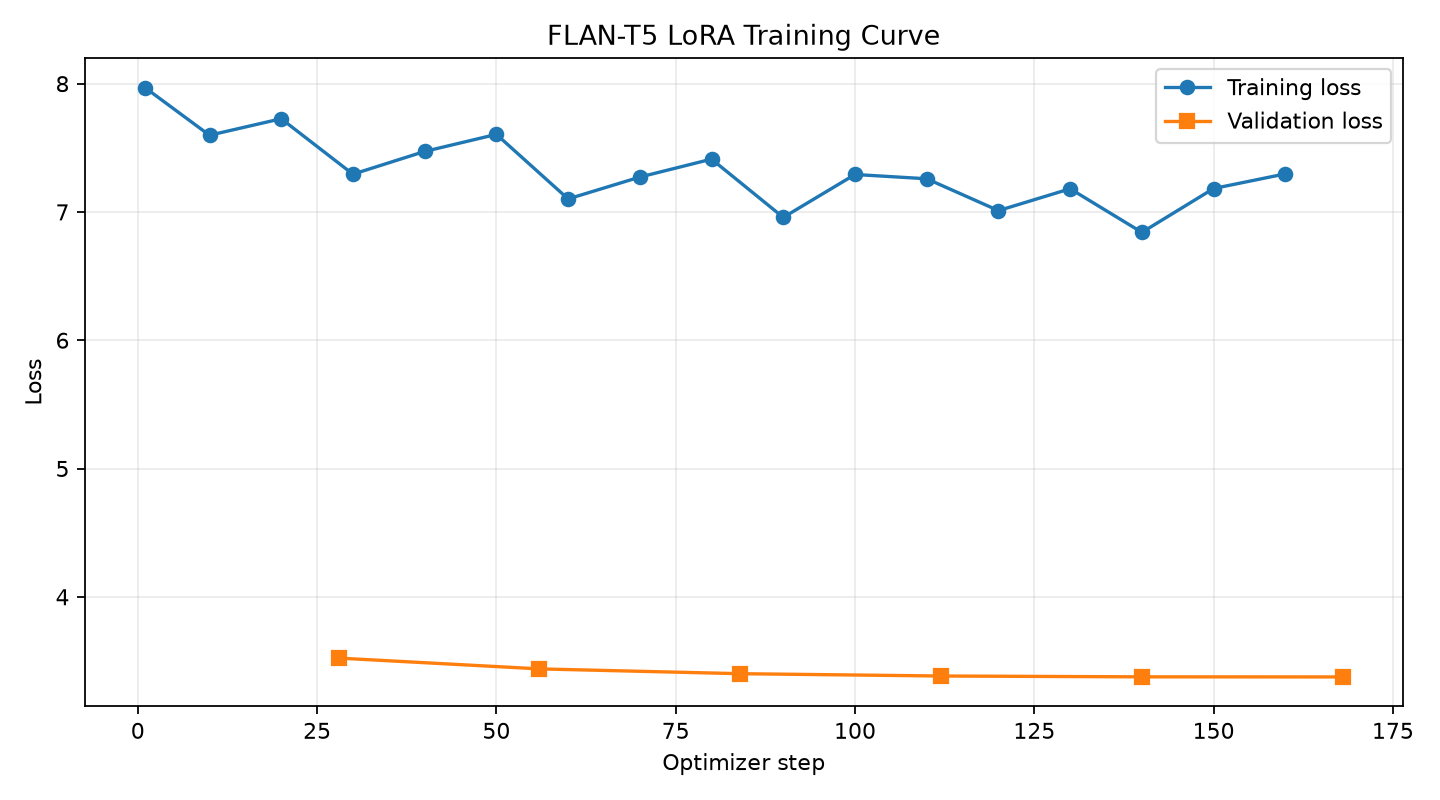

In [13]:
from IPython.display import Image, display as ipy_display

print(json.dumps(training_metadata.get("train_metrics", {}), indent=2))
print(json.dumps(training_metadata.get("validation_metrics", {}), indent=2))
print(json.dumps(training_metadata.get("test_metrics", {}), indent=2))
print("Validation perplexity:", training_metadata.get("validation_perplexity"))
ipy_display(Image(filename=str(training_dir / "training_curve.png")))

## 10. Run the held-out base-versus-LoRA benchmark

The base and adapted models receive identical deterministic prompts and generation settings. Models are unloaded between stages to control VRAM. BERTScore and semantic models are loaded only after response generation.

In [14]:
from src.advanced_evaluation import run_base_vs_lora_evaluation
from src.config import EvaluationConfig

evaluation_dir = RUN_DIR / "evaluation"
if RUN_EVALUATION:
    evaluation_manifest = run_base_vs_lora_evaluation(
        benchmark_path=benchmark_path,
        base_model_id=BASE_MODEL_ID,
        adapter_path=adapter_path,
        output_dir=evaluation_dir,
        evaluation_config=EvaluationConfig(
            bootstrap_samples=2000,
            include_bertscore=True,
            include_rouge=True,
            include_semantic_similarity=True,
        ),
    )
else:
    evaluation_manifest = json.loads((evaluation_dir / "evaluation_manifest.json").read_text())

display(evaluation_manifest["comparison"])

Loading weights: 100%|██████████| 282/282 [00:00<00:00, 10628.22it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 11366.36it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:

{'status': 'completed',
 'benchmark_examples': 80,
 'metric_comparison': {'instruction_adherence': {'base_mean': 0.623099,
   'lora_mean': 0.680236,
   'mean_delta': 0.057138,
   'delta_95_percent_ci': {'mean': 0.057138,
    'lower': 0.040372,
    'upper': 0.075148,
    'n': 80},
   'lora_win_rate': 0.75,
   'tie_rate': 0.0},
  'quality_rubric_score': {'base_mean': 0.57925,
   'lora_mean': 0.85425,
   'mean_delta': 0.275,
   'delta_95_percent_ci': {'mean': 0.275,
    'lower': 0.2485,
    'upper': 0.299,
    'n': 80},
   'lora_win_rate': 0.975,
   'tie_rate': 0.025},
  'rouge_l_f1': {'base_mean': 0.09508,
   'lora_mean': 0.146136,
   'mean_delta': 0.051056,
   'delta_95_percent_ci': {'mean': 0.051056,
    'lower': 0.037873,
    'upper': 0.065531,
    'n': 80},
   'lora_win_rate': 0.775,
   'tie_rate': 0.0},
  'semantic_similarity': {'base_mean': 0.346721,
   'lora_mean': 0.530597,
   'mean_delta': 0.183876,
   'delta_95_percent_ci': {'mean': 0.183876,
    'lower': 0.14043,
    'upper': 

## 11. Inspect overall and category-level improvements

A positive delta favors LoRA. The 95% bootstrap interval describes uncertainty for this held-out benchmark only; it is not a claim about universal performance.

In [15]:
comparison_path = evaluation_dir / "comparison" / "base_vs_lora_comparison.json"
comparison = json.loads(comparison_path.read_text())
comparison_table = pd.DataFrame(comparison["metric_comparison"]).T
comparison_table.index.name = "metric"
display(comparison_table[["base_mean", "lora_mean", "mean_delta", "lora_win_rate"]])

base_metrics = json.loads((evaluation_dir / "base_model" / "metrics.json").read_text())
lora_metrics = json.loads((evaluation_dir / "lora_model" / "metrics.json").read_text())
category_rows = []
for category in sorted(set(base_metrics["by_category"]) | set(lora_metrics["by_category"])):
    b = base_metrics["by_category"].get(category, {})
    l = lora_metrics["by_category"].get(category, {})
    category_rows.append({
        "category": category,
        "count": l.get("count", b.get("count")),
        "base_bertscore_f1": b.get("bertscore_f1"),
        "lora_bertscore_f1": l.get("bertscore_f1"),
        "base_quality": b.get("quality_rubric_score"),
        "lora_quality": l.get("quality_rubric_score"),
        "base_hallucination_rate": b.get("hallucination_flag_rate"),
        "lora_hallucination_rate": l.get("hallucination_flag_rate"),
    })
category_df = pd.DataFrame(category_rows)
display(category_df)

,base_mean,lora_mean,mean_delta,lora_win_rate
metric,,,,
instruction_adherence,0.623099,0.680236,0.057138,0.75
quality_rubric_score,0.57925,0.85425,0.275,0.975
rouge_l_f1,0.09508,0.146136,0.051056,0.775
semantic_similarity,0.346721,0.530597,0.183876,0.8375
bertscore_f1,0.850756,0.85392,0.003164,0.5625


,category,count,base_bertscore_f1,lora_bertscore_f1,base_quality,lora_quality,base_hallucination_rate,lora_hallucination_rate
0,Concept explanation,31,0.855897,0.857365,0.648387,0.921613,0.516129,0.193548
1,Metric explanation,9,0.838174,0.856097,0.596667,0.968889,1.000000,0.666667
2,Quality analytics,40,0.849604,0.850761,0.521750,0.776250,1.000000,0.725000


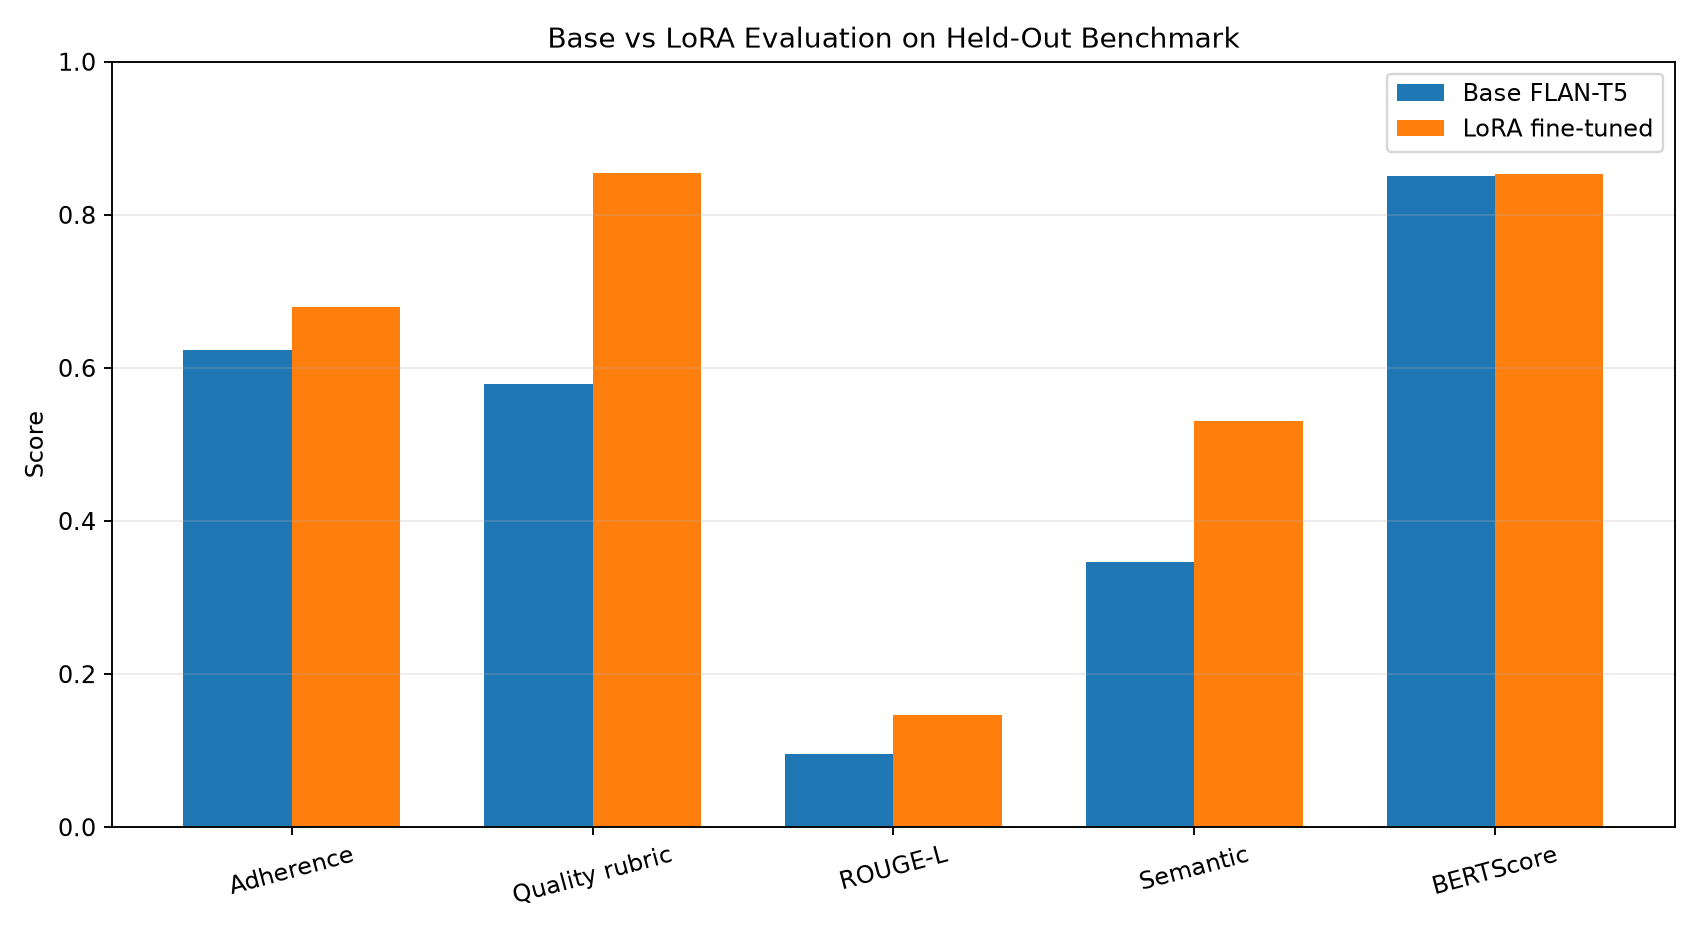

In [16]:
ipy_display(Image(filename=str(evaluation_dir / "comparison" / "base_vs_lora_metric_comparison.png")))

## 12. Complete human evaluation

Open `evaluation/comparison/per_example_base_vs_lora.csv` and fill in `human_preferred_model` and `human_notes`. Also complete the 1–5 ratings in each model's `manual_review_results.csv`. Review at least:

- all heuristic hallucination flags;
- all code answers;
- all advanced prompts;
- every example where LoRA performs worse than the base model;
- a random sample from every category.

Automated metrics must not replace factual review.

In [17]:
comparison_review_path = evaluation_dir / "comparison" / "per_example_base_vs_lora.csv"
review_df = pd.read_csv(comparison_review_path)
weak_or_flagged = review_df[
    (review_df["delta_bertscore_f1"] < 0)
    | (review_df["lora_hallucination_flag"] == True)
]
display(weak_or_flagged[["id", "prompt", "base_answer", "lora_answer", "delta_bertscore_f1", "lora_hallucination_flag"]])
print("Manual comparison file:", comparison_review_path)

,id,prompt,base_answer,lora_answer,delta_bertscore_f1,lora_hallucination_flag
0,benchmark_v2_000,Explain supervised learning accurately and inc...,A supervised learning system is a system that ...,A supervised learning model is a model that le...,-0.002610,False
1,benchmark_v2_001,Give a non-confidential quality analytics exam...,A manufacturing or process-quality setting wou...,Using a manufacturing or process-quality setti...,0.003366,True
4,benchmark_v2_004,Explain classification accurately and include ...,You are an educational ML and Data Science lea...,Classification is a classification of data tha...,0.013654,True
5,benchmark_v2_005,Give a non-confidential quality analytics exam...,Manufacturing or process-quality is a type of ...,Classification is a way of determining the qua...,-0.006439,True
6,benchmark_v2_006,Explain regression accurately and include one ...,Regression is not a linear regression.,Regression is a method of evaluating a model's...,-0.020723,False
8,benchmark_v2_008,Explain data leakage accurately and include on...,Data leakage is a problem that affects data qu...,Data leakage is a problem that occurs when a m...,-0.013495,False
9,benchmark_v2_009,Give a non-confidential quality analytics exam...,A manufacturing or process-quality setting wou...,Manufacturing or process-quality is a setting ...,-0.003479,True
11,benchmark_v2_011,Give a non-confidential quality analytics exam...,Manufacturing or process-quality setting.,Manufacturing or process-quality is a type of ...,0.001746,True
13,benchmark_v2_013,Give a non-confidential quality analytics exam...,Manufacturing is a process-quality setting.,A manufacturing or process-quality setting is ...,-0.004105,True
15,benchmark_v2_015,Give a non-confidential quality analytics exam...,Manufacturing or process-quality setting.,Manufacturing or process-quality settings can ...,0.010261,True


Manual comparison file: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\05-instruction-tuned-domain-llm\outputs\experiments\flan_t5_base_lora_20260730_120312\evaluation\comparison\per_example_base_vs_lora.csv


In [18]:
print("Comparison file:")
print(evaluation_dir / "comparison" / "per_example_base_vs_lora.csv")

print("\nBase-model review file:")
print(evaluation_dir / "base_model" / "manual_review_results.csv")

print("\nLoRA-model review file:")
print(evaluation_dir / "lora_model" / "manual_review_results.csv")

Comparison file:
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\05-instruction-tuned-domain-llm\outputs\experiments\flan_t5_base_lora_20260730_120312\evaluation\comparison\per_example_base_vs_lora.csv

Base-model review file:
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\05-instruction-tuned-domain-llm\outputs\experiments\flan_t5_base_lora_20260730_120312\evaluation\base_model\manual_review_results.csv

LoRA-model review file:
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\05-instruction-tuned-domain-llm\outputs\experiments\flan_t5_base_lora_20260730_120312\evaluation\lora_model\manual_review_results.csv


## 13. Portfolio release gate

After completing human review, set both variables to `True`. Promotion copies the trained adapter and verified result files into the standard `models/` and `outputs/` locations used by the Gradio app and Git repository.

In [ ]:
EVALUATION_HUMAN_REVIEW_COMPLETED = True  
PROMOTE_REVIEWED_ARTIFACTS = False          # Change when ready to create the release candidate.

from src.release_utils import promote_experiment

if PROMOTE_REVIEWED_ARTIFACTS:
    release_manifest = promote_experiment(
        project_root=PROJECT_ROOT,
        experiment_dir=RUN_DIR,
        human_review_completed=EVALUATION_HUMAN_REVIEW_COMPLETED,
    )
    display(release_manifest)
else:
    print("Promotion skipped. This prevents unreviewed results from being presented as final.")

## 14. Test the deployment model locally

After promotion, `app.py` will load `models/lora_adapter`. Confirm that the app reports `lora_adapter`, not `base_model_fallback`.

In [ ]:
# Run this after promotion, then open the local Gradio URL.
# !python app.py

## 15. Optional: publish the adapter to Hugging Face Hub

Authenticate with `huggingface-cli login` or `hf auth login`. Publish the adapter rather than the full base model; the Space can load `google/flan-t5-base` and then your compact PEFT adapter.

In [ ]:
if PUSH_ADAPTER_TO_HUB:
    if "YOUR_HUGGINGFACE_USERNAME" in HF_ADAPTER_REPO:
        raise ValueError("Set HF_USERNAME before pushing.")
    from huggingface_hub import HfApi
    api = HfApi()
    api.create_repo(repo_id=HF_ADAPTER_REPO, repo_type="model", exist_ok=True)
    api.upload_folder(
        repo_id=HF_ADAPTER_REPO,
        repo_type="model",
        folder_path=str(adapter_path),
    )
    print("Published adapter:", HF_ADAPTER_REPO)
else:
    print("Hub push skipped. Set PUSH_ADAPTER_TO_HUB = True when ready.")

## 16. Git commands after verification

Commit generated artifacts only after checking file sizes and completing human review. Do not push checkpoints, caches, the raw teacher model, or private data.

In [ ]:
print(rf"""
cd "{PROJECT_ROOT}"

git status
git add data/ml_ds_instruction_dataset_v2.jsonl         data/benchmark_prompts_v2.jsonl         data/dataset_generation_plan.json         notebooks/05_full_training_evaluation_pipeline.ipynb         src scripts tests requirements-training.txt README.md MODEL_CARD.md DATASET_CARD.md         models/lora_adapter models/tokenizer models/model_metadata.json         outputs/training_curve.png outputs/training_log_history.json         outputs/base_model_metrics.json outputs/lora_model_metrics.json         outputs/base_vs_lora_comparison.json outputs/per_example_base_vs_lora.csv         outputs/before_after_finetuning_examples.md         outputs/base_vs_lora_metric_comparison.png outputs/evaluation_manifest.json         outputs/release_manifest.json

git commit -m "Add FLAN-T5 LoRA training evidence and benchmark evaluation for Project 05"
git push origin main

# Push adapter weights to the separate Hugging Face model repository, not ordinary Git history.
""")

## 17. Calculate the evidence-based portfolio readiness score

This is a project-completion score, not a universal model-quality score. The 9/10 target requires trained weights, real benchmark values, human review, and deployment evidence.

In [ ]:
from src.portfolio_readiness import assess_portfolio_readiness

readiness = assess_portfolio_readiness(PROJECT_ROOT)
(PROJECT_ROOT / "outputs" / "portfolio_readiness_report.json").write_text(
    json.dumps(readiness, indent=2), encoding="utf-8"
)
display(readiness)

## Completion checklist

Project 05 reaches the intended portfolio standard only when all items are true:

- expanded dataset reviewed and committed;
- trained adapter files exist;
- real training curve and metadata exist;
- base and LoRA models were evaluated on the same held-out benchmark;
- BERTScore, ROUGE-L, semantic similarity, adherence, latency, and hallucination-risk outputs contain real values;
- confidence intervals and category-level results were saved;
- human review was completed;
- Gradio reports `lora_adapter`;
- Hugging Face model and Space links were added to the README and model card.